In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("/content/Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [ ]:
print(df.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')


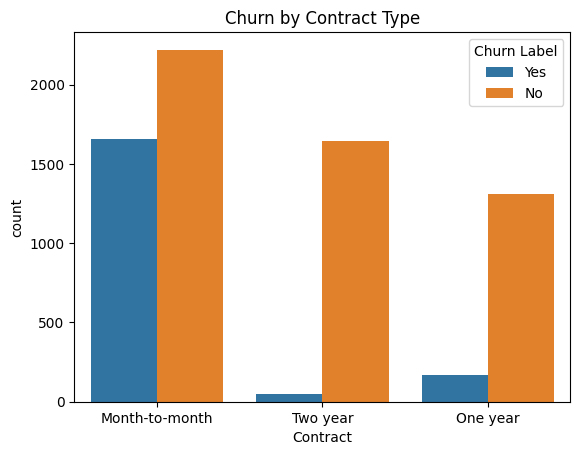

In [ ]:
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Churn by Contract Type")
plt.show()

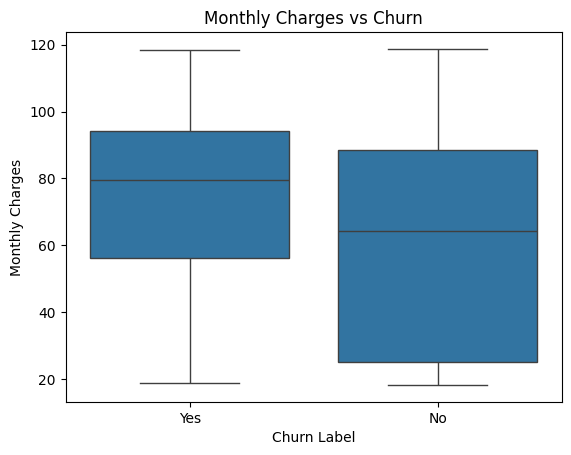

In [ ]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [ ]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [ ]:
df = df.dropna(subset=["Total Charges"])

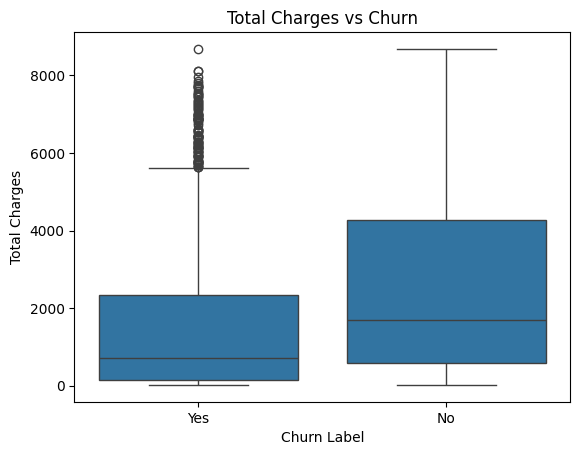

In [ ]:
sns.boxplot(x="Churn Label", y="Total Charges", data=df)

plt.title("Total Charges vs Churn")

plt.show()

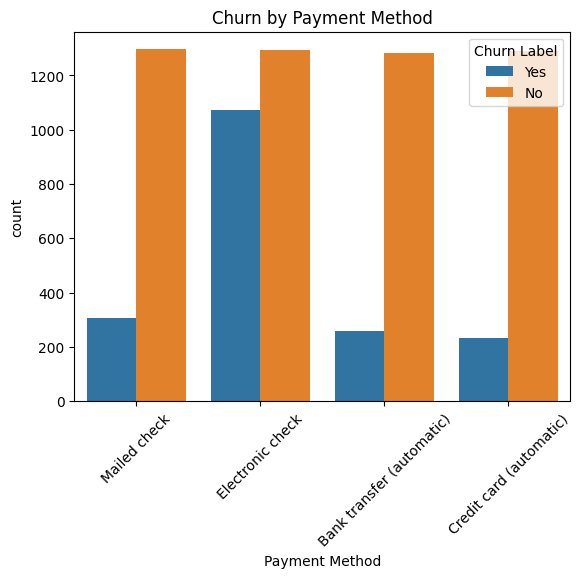

In [ ]:
sns.countplot(x="Payment Method", hue="Churn Label", data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")

plt.show()

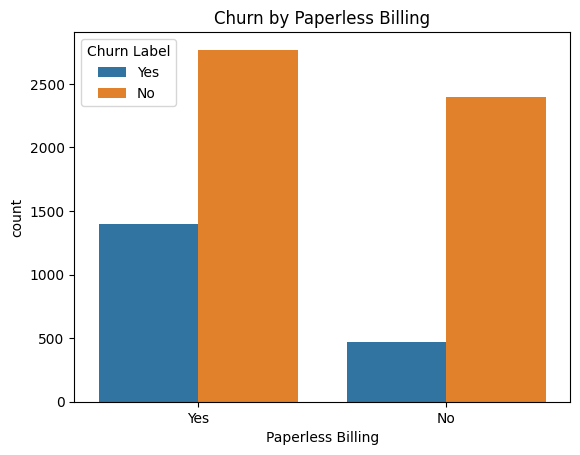

In [ ]:
sns.countplot(x="Paperless Billing", hue="Churn Label", data=df)
plt.title("Churn by Paperless Billing")
plt.show()

In [ ]:
features = [
    "Monthly Charges",
    "Total Charges",
   "Contract",
    "Payment Method",
    "Paperless Billing"
]

X = df[features]
y = df["Churn Label"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

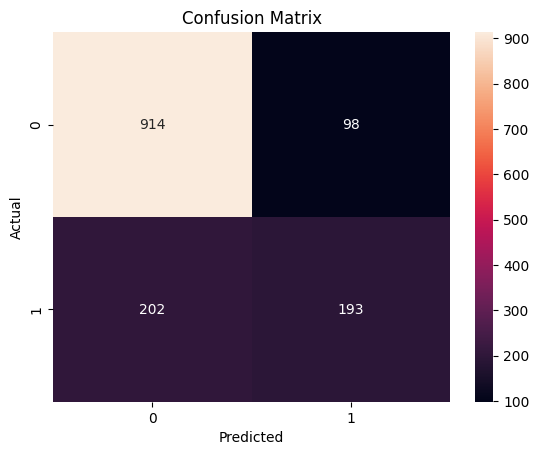

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7867803837953091


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
5,Payment Method_Electronic check,0.486677
7,Paperless Billing_Yes,0.480813
6,Payment Method_Mailed check,0.031037
0,Monthly Charges,0.028230
1,Total Charges,-0.000341
4,Payment Method_Credit card (automatic),-0.169353
2,Contract_One year,-1.017865
3,Contract_Two year,-2.030319


### **Key Insights**

1. Contract Type

Customers with month-to-month contracts have the highest churn rate compared to long-term contracts.

2. Payment Method

Customers paying via electronic check show higher churn compared to other payment methods.

3. Monthly Charges

Higher monthly charges are associated with a higher probability of churn.

4. Paperless Billing

Customers using paperless billing show a slightly higher churn rate.

⸻

#**Model Performance**

A logistic regression model was used to predict customer churn.

The model achieved approximately 80% accuracy on the test dataset.

The confusion matrix shows the model can correctly classify most churn and non-churn customers.
